In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import astropy.units as units
import astropy.constants as const
from scipy.special import wofz
from tqdm import tqdm
from rtfunctions import one_full_fs, sc_2nd_order, calc_lambda_full, calc_lambda_monoc
import time
import illuminated_finite_slab as ill
import SLab_linev2 as v2 # Latest version

<h1>Can Mihalas plots be reproduced?</h1>
<p>In Mihalas' book, there are plots of the source function and the mean intensity for a two-level atom with a given line profile. The question is whether these plots can be reproduced using the code in SLab_linev2.py.</p>
<p>To reproduce Mihalas' plots, we need to ensure that we are using the same parameters and assumptions as Mihalas did in his calculations. This includes the line profile, the optical depth, and the source function. We also need to make sure that we are correctly computing the mean intensity and the source function for the two-level atom.</p>


<h2>SLab_linev2 - one line a = 0.0, Figure 11.3</h2>

In [2]:
# Create a slab
# Define the input parameters
ND = 91
tau_max = 1e4
epsilon_m2 = np.ones(ND) * 1e-2
B = np.ones(ND) * 1.0
H = 80000.0 # Height of the slab above the solar surface in kilometers
slab_one_line = v2.Slab(ND, tau_max, epsilon_m2, B, H)

line_one_1 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line)
lines_one = [line_one_1]
slab_one_line.global_x_grid(lines_one)
line_one_1.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line.x_values)
result_one = slab_one_line.iterate_coupled_lines(lines_one, max_iter=2000, tol=1e-6, verbose=False)

  6%|▌         | 59/1000 [00:01<00:18, 50.99it/s]


Convergence achieved after 59 iterations with max dS = 8.20e-07


  0%|          | 3/2000 [00:00<03:10, 10.47it/s]


In [3]:
epsilon_m4 = np.ones(ND) * 1e-4
epsilon_m6 = np.ones(ND) * 1e-6
epsilon_m8 = np.ones(ND) * 1e-8
epsilon_m10 = np.ones(ND) * 1e-10

In [4]:
slab_one_line_m4 = v2.Slab(ND, tau_max, epsilon_m4, B, H)
line_one_1_m4 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line_m4)
lines_one_m4 = [line_one_1_m4]
slab_one_line_m4.global_x_grid(lines_one_m4)
line_one_1_m4.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_m4.x_values)
result_one_m4 = slab_one_line_m4.iterate_coupled_lines(lines_one_m4, max_iter=2000, tol=1e-6, verbose=False)    

 11%|█▏        | 114/1000 [00:01<00:08, 101.18it/s]


Convergence achieved after 114 iterations with max dS = 9.82e-07


  2%|▏         | 38/2000 [00:00<00:23, 84.20it/s]


In [5]:
slab_one_line_m6 = v2.Slab(ND, tau_max, epsilon_m6, B, H)
line_one_1_m6 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line_m6)
lines_one_m6 = [line_one_1_m6]     
slab_one_line_m6.global_x_grid(lines_one_m6)
line_one_1_m6.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_m6.x_values)
result_one_m6 = slab_one_line_m6.iterate_coupled_lines(lines_one_m6, max_iter=2000, tol=1e-6, verbose=False)

 13%|█▎        | 133/1000 [00:01<00:08, 103.40it/s]


Convergence achieved after 133 iterations with max dS = 9.86e-07


 38%|███▊      | 765/2000 [00:08<00:14, 85.02it/s]


In [6]:
slab_one_line_m8 = v2.Slab(ND, tau_max, epsilon_m8, B, H)
line_one_1_m8 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line_m8)
lines_one_m8 = [line_one_1_m8]
slab_one_line_m8.global_x_grid(lines_one_m8)
line_one_1_m8.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_m8.x_values)
result_one_m8 = slab_one_line_m8.iterate_coupled_lines(lines_one_m8, max_iter=2000, tol=1e-6, verbose=False)

 13%|█▎        | 134/1000 [00:01<00:08, 101.95it/s]


Convergence achieved after 134 iterations with max dS = 9.49e-07


100%|██████████| 2000/2000 [00:25<00:00, 79.42it/s]


In [7]:
slab_one_line_m10 = v2.Slab(ND, tau_max, epsilon_m10, B, H)
line_one_1_m10 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line_m10)
lines_one_m10 = [line_one_1_m10]
slab_one_line_m10.global_x_grid(lines_one_m10)
line_one_1_m10.compute_S_line(max_iter = 1000, tol =    1e-6, global_x_grid = slab_one_line_m10.x_values)
result_one_m10 = slab_one_line_m10.iterate_coupled_lines(lines_one_m10, max_iter=2000, tol=1e-6, verbose=False)

 13%|█▎        | 134/1000 [00:01<00:08, 99.82it/s] 


Convergence achieved after 134 iterations with max dS = 9.50e-07


100%|██████████| 2000/2000 [00:25<00:00, 79.51it/s]


In [8]:
S_e2 = result_one['S_lines'][0]
I_e2 = result_one['I_emergent']

S_e4 = result_one_m4['S_lines'][0]
I_e4 = result_one_m4['I_emergent']

S_e6 = result_one_m6['S_lines'][0]
I_e6 = result_one_m6['I_emergent']

S_e8 = result_one_m8['S_lines'][0]
I_e8 = result_one_m8['I_emergent']

S_e10 = result_one_m10['S_lines'][0]
I_e10 = result_one_m10['I_emergent']

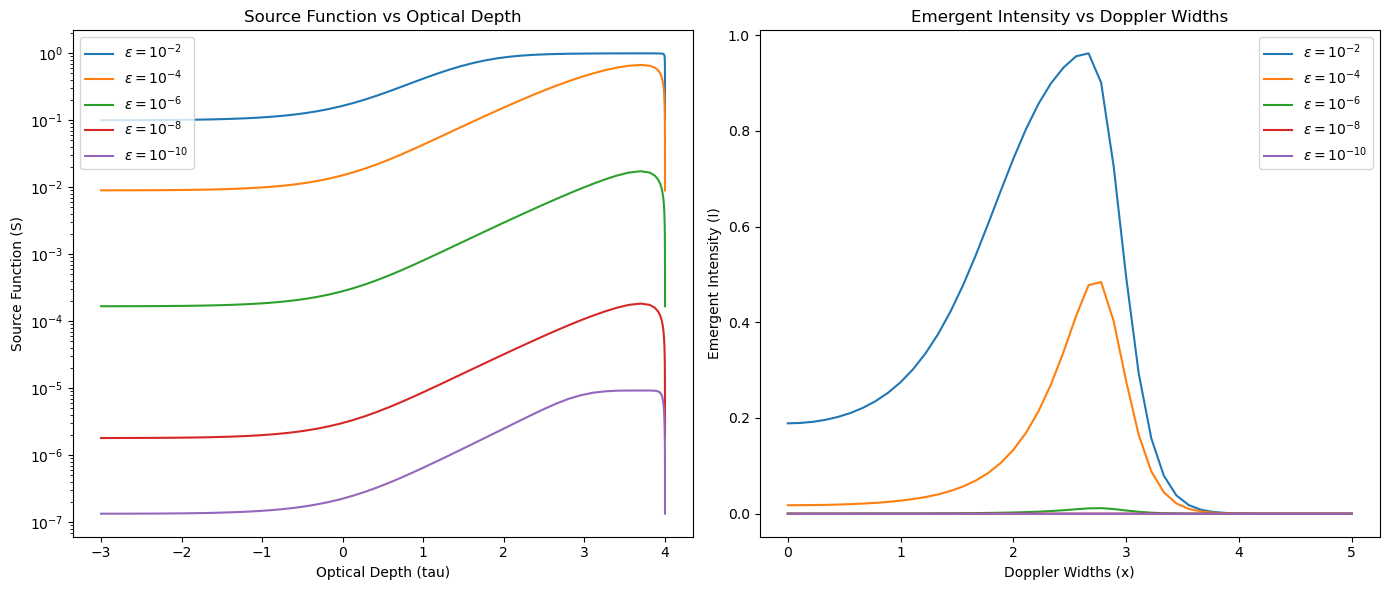

In [9]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.semilogy(np.log10(slab_one_line.tau), S_e2, label=r'$\epsilon = 10^{-2}$')
plt.semilogy(np.log10(slab_one_line_m4.tau), S_e4, label=r'$\epsilon = 10^{-4}$')
plt.semilogy(np.log10(slab_one_line_m6.tau), S_e6, label=r'$\epsilon = 10^{-6}$')
plt.semilogy(np.log10(slab_one_line_m8.tau), S_e8, label=r'$\epsilon = 10^{-8}$')
plt.semilogy(np.log10(slab_one_line_m10.tau), S_e10, label=r'$\epsilon = 10^{-10}$')
plt.xlabel('Optical Depth (tau)')
plt.ylabel('Source Function (S)')
plt.title('Source Function vs Optical Depth')
plt.legend()
plt.subplot(1, 2, 2)
midpoint = len(slab_one_line.x_values) // 2
I_e2_half = I_e2[midpoint:]
I_e4_half = I_e4[midpoint:]
I_e6_half = I_e6[midpoint:]
I_e8_half = I_e8[midpoint:]
I_e10_half = I_e10[midpoint:]
plt.plot(slab_one_line.x_values[midpoint:], I_e2_half, label=r'$\epsilon = 10^{-2}$')
plt.plot(slab_one_line_m4.x_values[midpoint:], I_e4_half, label=r'$\epsilon = 10^{-4}$')
plt.plot(slab_one_line_m6.x_values[midpoint:], I_e6_half, label=r'$\epsilon = 10^{-6}$')
plt.plot(slab_one_line_m8.x_values[midpoint:], I_e8_half, label=r'$\epsilon = 10^{-8}$')
plt.plot(slab_one_line_m10.x_values[midpoint:], I_e10_half, label=r'$\epsilon = 10^{-10}$')
plt.xlabel('Doppler Widths (x)')
plt.ylabel('Emergent Intensity (I)')
plt.title('Emergent Intensity vs Doppler Widths')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
print(I_e10)

[6.59847048e-13 1.97984417e-12 5.79555929e-12 1.65514558e-11
 4.61161709e-11 1.25356160e-10 3.32438646e-10 8.60093661e-10
 2.17088332e-09 5.34510020e-09 1.28363190e-08 3.00573233e-08
 6.85778479e-08 1.52233914e-07 3.27836295e-07 6.80960914e-07
 1.34961692e-06 2.50360611e-06 4.21245259e-06 6.15286788e-06
 7.48378850e-06 7.58769132e-06 6.83671521e-06 5.79374193e-06
 4.69407839e-06 3.68103174e-06 2.84027115e-06 2.18903445e-06
 1.70200662e-06 1.34178037e-06 1.07489383e-06 8.75851396e-07
 7.26262541e-07 6.13021442e-07 5.26748941e-07 4.60671451e-07
 4.09851679e-07 3.70663690e-07 3.40431077e-07 3.17173873e-07
 2.99429058e-07 2.86122113e-07 2.76474907e-07 2.69940209e-07
 2.66156294e-07 2.64917264e-07 2.66156294e-07 2.69940209e-07
 2.76474907e-07 2.86122113e-07 2.99429058e-07 3.17173873e-07
 3.40431077e-07 3.70663690e-07 4.09851679e-07 4.60671451e-07
 5.26748941e-07 6.13021442e-07 7.26262541e-07 8.75851396e-07
 1.07489383e-06 1.34178037e-06 1.70200662e-06 2.18903445e-06
 2.84027115e-06 3.681031

<h2>SLab_linev2 - one line a = {0.0; 0.01, 0.001}, Figure 11.4</h2>

In [11]:
ND = 91
tau_max_dep2 = 1e2
B = np.ones(ND) * 1.0
H = 80000.0 # Height of the slab above the solar surface in kilometers
slab_one_line_dep2 = v2.Slab(ND, tau_max_dep2, epsilon_m4, B, H)

line_one_0_dep2 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line_dep2)
lines_one_0_dep2 = [line_one_0_dep2]

line_one_02_dep2 = v2.Slab.Line(ND, line_center=0.0, a=0.01, k=1.0, slab_in=slab_one_line_dep2)
lines_one_02_dep2 = [line_one_02_dep2]

line_one_03_dep2 = v2.Slab.Line(ND, line_center=0.0, a=0.001, k=1.0, slab_in=slab_one_line_dep2)
lines_one_03_dep2 = [line_one_03_dep2]

slab_one_line_dep2.global_x_grid(lines_one_0_dep2)
line_one_0_dep2.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep2.x_values)
result_one_0_dep2 = slab_one_line_dep2.iterate_coupled_lines(lines_one_0_dep2, max_iter=2000, tol=1e-6, verbose=False)

slab_one_line_dep2.global_x_grid(lines_one_02_dep2)
line_one_02_dep2.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep2.x_values)
result_one_02_dep2 = slab_one_line_dep2.iterate_coupled_lines(lines_one_02_dep2, max_iter=2000, tol=1e-6, verbose=False)

slab_one_line_dep2.global_x_grid(lines_one_03_dep2)
line_one_03_dep2.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep2.x_values)
result_one_03_dep2 = slab_one_line_dep2.iterate_coupled_lines(lines_one_03_dep2, max_iter=2000, tol=1e-6, verbose=False)

S_0_dep2 = result_one_0_dep2['S_lines'][0]
I_0_dep2 = result_one_0_dep2['I_emergent']

S_02_dep2 = result_one_02_dep2['S_lines'][0]
I_02_dep2 = result_one_02_dep2['I_emergent']

S_03_dep2 = result_one_03_dep2['S_lines'][0]
I_03_dep2 = result_one_03_dep2['I_emergent']

 14%|█▍        | 140/1000 [00:01<00:08, 96.06it/s]


Convergence achieved after 140 iterations with max dS = 9.62e-07


 13%|█▎        | 126/1000 [00:01<00:08, 99.02it/s] 


Convergence achieved after 126 iterations with max dS = 9.97e-07


 14%|█▍        | 138/1000 [00:01<00:08, 98.21it/s] 


Convergence achieved after 138 iterations with max dS = 9.89e-07


 12%|█▏        | 237/2000 [00:02<00:22, 79.30it/s]


In [12]:
tau_max_dep4 = 1e4
slab_one_line_dep4 = v2.Slab(ND, tau_max_dep4, epsilon_m4, B, H)

line_one_0_dep4 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line_dep4)
lines_one_0_dep4 = [line_one_0_dep4]
line_one_02_dep4 = v2.Slab.Line(ND, line_center=0.0, a=0.01, k=1.0, slab_in=slab_one_line_dep4)
lines_one_02_dep4 = [line_one_02_dep4]
line_one_03_dep4 = v2.Slab.Line(ND, line_center=0.0, a=0.001, k=1.0, slab_in=slab_one_line_dep4)
lines_one_03_dep4 = [line_one_03_dep4]

slab_one_line_dep4.global_x_grid(lines_one_0_dep4)
line_one_0_dep4.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep4.x_values)
result_one_0_dep4 = slab_one_line_dep4.iterate_coupled_lines(lines_one_0_dep4, max_iter=2000, tol=1e-6, verbose=False)

slab_one_line_dep4.global_x_grid(lines_one_02_dep4)
line_one_02_dep4.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep4.x_values)
result_one_02_dep4 = slab_one_line_dep4.iterate_coupled_lines(lines_one_02_dep4, max_iter=2000, tol=1e-6, verbose=False)

slab_one_line_dep4.global_x_grid(lines_one_03_dep4)
line_one_03_dep4.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep4.x_values)
result_one_03_dep4 = slab_one_line_dep4.iterate_coupled_lines(lines_one_03_dep4, max_iter=2000, tol=1e-6, verbose=False)

S_0_dep4 = result_one_0_dep4['S_lines'][0]
I_0_dep4 = result_one_0_dep4['I_emergent']

S_02_dep4 = result_one_02_dep4['S_lines'][0]
I_02_dep4 = result_one_02_dep4['I_emergent']

S_03_dep4 = result_one_03_dep4['S_lines'][0]
I_03_dep4 = result_one_03_dep4['I_emergent']

 11%|█▏        | 114/1000 [00:01<00:08, 102.02it/s]


Convergence achieved after 114 iterations with max dS = 9.82e-07


 10%|▉         | 96/1000 [00:00<00:08, 106.03it/s]


Convergence achieved after 96 iterations with max dS = 8.89e-07


 11%|█         | 110/1000 [00:01<00:08, 102.70it/s]


Convergence achieved after 110 iterations with max dS = 9.07e-07


  2%|▏         | 41/2000 [00:00<00:23, 83.43it/s]


In [13]:
tau_max_dep6 = 1e6
slab_one_line_dep6 = v2.Slab(ND, tau_max_dep6, epsilon_m4, B, H)

line_one_0_dep6 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line_dep6)
lines_one_0_dep6 = [line_one_0_dep6]
line_one_02_dep6 = v2.Slab.Line(ND, line_center=0.0, a=0.01, k=1.0, slab_in=slab_one_line_dep6)
lines_one_02_dep6 = [line_one_02_dep6]
line_one_03_dep6 = v2.Slab.Line(ND, line_center=0.0, a=0.001, k=1.0, slab_in=slab_one_line_dep6)
lines_one_03_dep6 = [line_one_03_dep6]

slab_one_line_dep6.global_x_grid(lines_one_0_dep6)
line_one_0_dep6.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep6.x_values)
result_one_0_dep6 = slab_one_line_dep6.iterate_coupled_lines(lines_one_0_dep6, max_iter=2000, tol=1e-6, verbose=False)

slab_one_line_dep6.global_x_grid(lines_one_02_dep6)
line_one_02_dep6.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep6.x_values)
result_one_02_dep6 = slab_one_line_dep6.iterate_coupled_lines(lines_one_02_dep6, max_iter=2000, tol=1e-6, verbose=False)

slab_one_line_dep6.global_x_grid(lines_one_03_dep6)
line_one_03_dep6.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep6.x_values)
result_one_03_dep6 = slab_one_line_dep6.iterate_coupled_lines(lines_one_03_dep6, max_iter=2000, tol=1e-6, verbose=False)

S_0_dep6 = result_one_0_dep6['S_lines'][0]
I_0_dep6 = result_one_0_dep6['I_emergent']

S_02_dep6 = result_one_02_dep6['S_lines'][0]
I_02_dep6 = result_one_02_dep6['I_emergent']

S_03_dep6 = result_one_03_dep6['S_lines'][0]
I_03_dep6 = result_one_03_dep6['I_emergent']

  0%|          | 0/1000 [00:00<?, ?it/s]

  9%|▊         | 86/1000 [00:00<00:09, 97.75it/s] 


Convergence achieved after 86 iterations with max dS = 9.83e-07


  7%|▋         | 73/1000 [00:00<00:09, 102.52it/s]


Convergence achieved after 73 iterations with max dS = 9.57e-07


  8%|▊         | 83/1000 [00:00<00:08, 102.90it/s]


Convergence achieved after 83 iterations with max dS = 9.38e-07


  1%|▏         | 27/2000 [00:00<00:23, 82.47it/s]


In [14]:
tau_max_dep8 = 1e8
slab_one_line_dep8 = v2.Slab(ND, tau_max_dep8, epsilon_m4, B, H)

line_one_0_dep8 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line_dep8)
lines_one_0_dep8 = [line_one_0_dep8]
line_one_02_dep8 = v2.Slab.Line(ND, line_center=0.0, a=0.01, k=1.0, slab_in=slab_one_line_dep8)
lines_one_02_dep8 = [line_one_02_dep8]
line_one_03_dep8 = v2.Slab.Line(ND, line_center=0.0, a=0.001, k=1.0, slab_in=slab_one_line_dep8)
lines_one_03_dep8 = [line_one_03_dep8]

slab_one_line_dep8.global_x_grid(lines_one_0_dep8)
line_one_0_dep8.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep8.x_values)
result_one_0_dep8 = slab_one_line_dep8.iterate_coupled_lines(lines_one_0_dep8, max_iter=2000, tol=1e-6, verbose=False)

slab_one_line_dep8.global_x_grid(lines_one_02_dep8)
line_one_02_dep8.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep8.x_values)
result_one_02_dep8 = slab_one_line_dep8.iterate_coupled_lines(lines_one_02_dep8, max_iter=2000, tol=1e-6, verbose=False)

slab_one_line_dep8.global_x_grid(lines_one_03_dep8)
line_one_03_dep8.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep8.x_values)
result_one_03_dep8 = slab_one_line_dep8.iterate_coupled_lines(lines_one_03_dep8, max_iter=2000, tol=1e-6, verbose=False)

S_0_dep8 = result_one_0_dep8['S_lines'][0]
I_0_dep8 = result_one_0_dep8['I_emergent']

S_02_dep8 = result_one_02_dep8['S_lines'][0]
I_02_dep8 = result_one_02_dep8['I_emergent']

S_03_dep8 = result_one_03_dep8['S_lines'][0]
I_03_dep8 = result_one_03_dep8['I_emergent']

  0%|          | 0/1000 [00:00<?, ?it/s]

  7%|▋         | 69/1000 [00:00<00:10, 90.83it/s]


Convergence achieved after 69 iterations with max dS = 8.83e-07


  6%|▌         | 59/1000 [00:00<00:09, 99.85it/s] 


Convergence achieved after 59 iterations with max dS = 9.46e-07


  7%|▋         | 66/1000 [00:00<00:09, 99.40it/s] 


Convergence achieved after 66 iterations with max dS = 9.70e-07


  1%|          | 23/2000 [00:00<00:24, 80.70it/s]


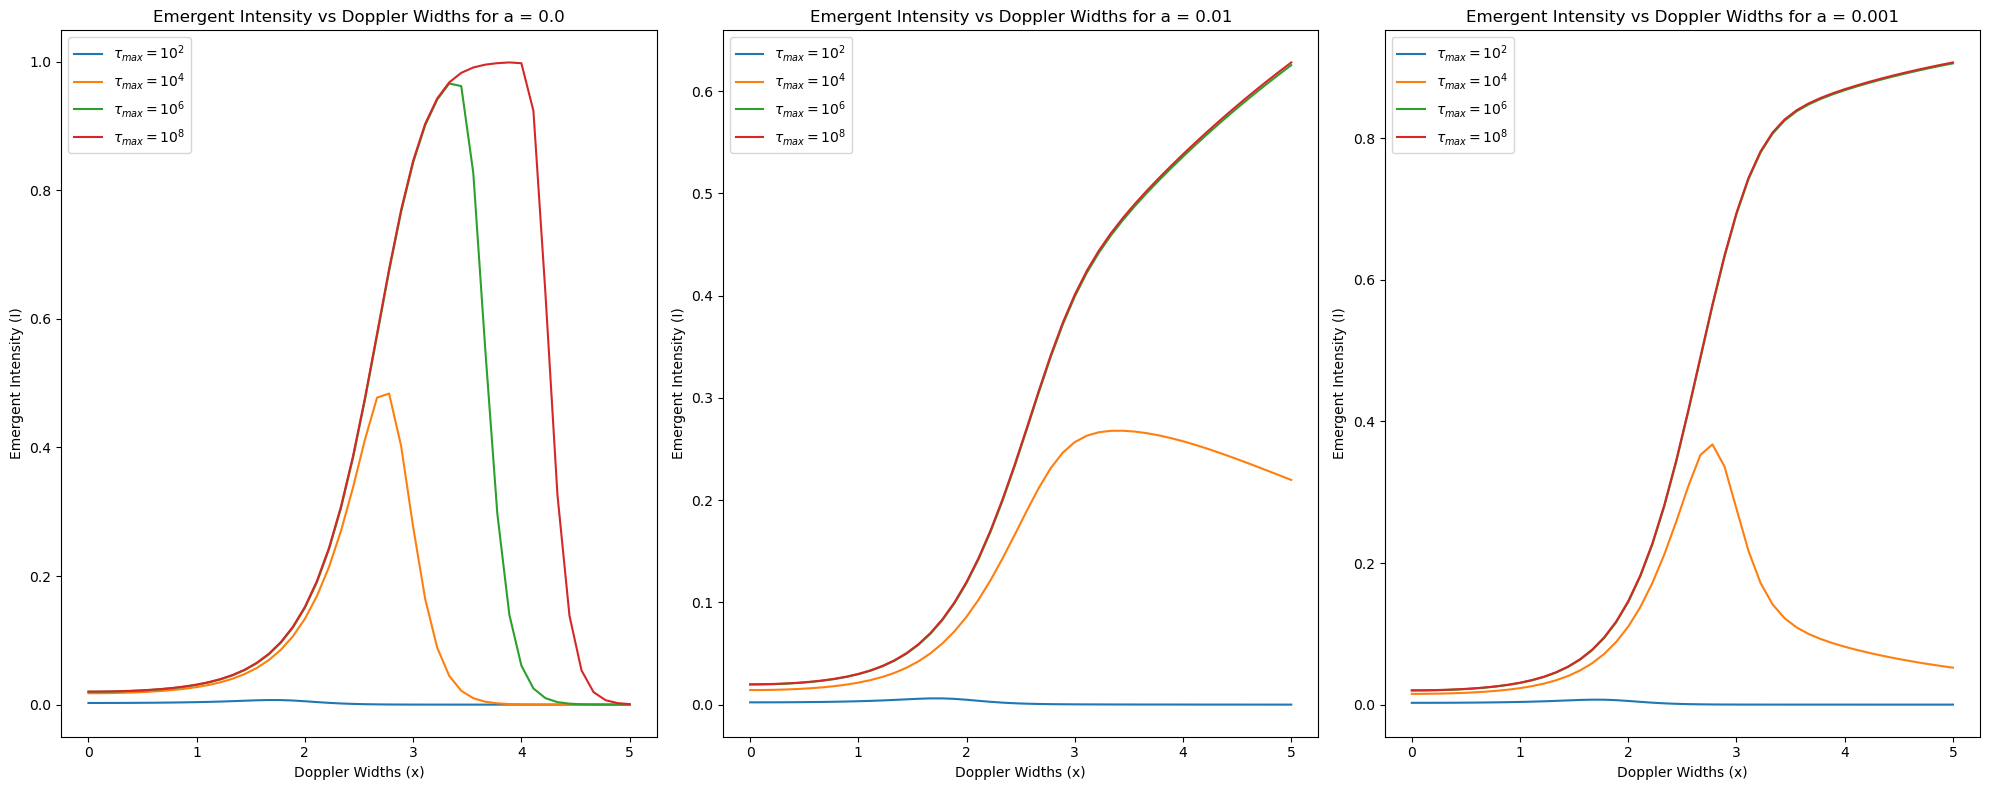

In [15]:
plt.figure(figsize=(20, 8))
midpoint = len(slab_one_line_dep2.x_values) // 2
plt.subplot(1, 3, 1)
plt.plot(slab_one_line_dep2.x_values[midpoint:], I_0_dep2[midpoint:], label=r'$\tau_{max} = 10^2$')
plt.plot(slab_one_line_dep4.x_values[midpoint:], I_0_dep4[midpoint:], label=r'$\tau_{max} = 10^4$')
plt.plot(slab_one_line_dep6.x_values[midpoint:], I_0_dep6[midpoint:], label=r'$\tau_{max} = 10^6$')
plt.plot(slab_one_line_dep8.x_values[midpoint:], I_0_dep8[midpoint:], label=r'$\tau_{max} = 10^8$')
plt.xlabel('Doppler Widths (x)')
plt.ylabel('Emergent Intensity (I)')
plt.title('Emergent Intensity vs Doppler Widths for a = 0.0')
plt.legend()
plt.subplot(1, 3, 2)
plt.plot(slab_one_line_dep2.x_values[midpoint:], I_02_dep2[midpoint:], label=r'$\tau_{max} = 10^2$')
plt.plot(slab_one_line_dep4.x_values[midpoint:], I_02_dep4[midpoint:], label=r'$\tau_{max} = 10^4$')
plt.plot(slab_one_line_dep6.x_values[midpoint:], I_02_dep6[midpoint:], label=r'$\tau_{max} = 10^6$')
plt.plot(slab_one_line_dep8.x_values[midpoint:], I_02_dep8[midpoint:], label=r'$\tau_{max} = 10^8$')
plt.xlabel('Doppler Widths (x)')
plt.ylabel('Emergent Intensity (I)')
plt.title('Emergent Intensity vs Doppler Widths for a = 0.01')
plt.legend()
plt.subplot(1, 3, 3)
plt.plot(slab_one_line_dep2.x_values[midpoint:], I_03_dep2[midpoint:], label=r'$\tau_{max} = 10^2$')
plt.plot(slab_one_line_dep4.x_values[midpoint:], I_03_dep4[midpoint:], label=r'$\tau_{max} = 10^4$')
plt.plot(slab_one_line_dep6.x_values[midpoint:], I_03_dep6[midpoint:], label=r'$\tau_{max} = 10^6$')
plt.plot(slab_one_line_dep8.x_values[midpoint:], I_03_dep8[midpoint:], label=r'$\tau_{max} = 10^8$')
plt.xlabel('Doppler Widths (x)')
plt.ylabel('Emergent Intensity (I)')
plt.title('Emergent Intensity vs Doppler Widths for a = 0.001')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
S_0_dep2_nu = result_one_0_dep2['S_nu']

In [17]:
np.shape(S_0_dep2_nu)

(91, 91)